# 04 · Deep Q-networks from scratch

[Course README](../README.md) · README topics **21–24**

**Goal.** Replace a Q-table with a neural network, implement replay and target networks, and verify frozen-policy performance across seeds.

**How to run:** select **Restart Kernel and Run All**. Every required function is defined
in this notebook; run cells in order. The defaults are small CPU experiments, not benchmark
training runs. Install the root `requirements.txt` once before opening Jupyter.
No cells install packages, download data, or require account credentials.

<img src="../assets/diagrams/experience-replay.svg" width="760" alt="Overview of Deep Q-networks from scratch">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/04_dqn.ipynb)

[Reproducibility guide](../REPRODUCIBILITY.md) · [Integrated comparison lab](08_one_problem_many_algorithms.ipynb)

## 1. A small environment makes the learning loop visible

The robot moves left or right on a line of nine positions. Position 0 is failure and
position 8 is successful delivery. Each episode starts uniformly at positions 1–7.
Ordinary moves pay **−0.02**, delivery pays **+1**, and failure pays **−1**. The terminal
reward replaces the movement cost. The task also ends after 20 actions; that finite task
horizon is a true terminal boundary, not an external rollout truncation.

The observation contains **normalized position and remaining time**. Including time makes
the finite-horizon task Markov. Both actions are discrete, which makes the DQN maximum easy
to compute. We intentionally use a tiny environment rather than a benchmark requiring
external packages or a GPU. Learning this task is a correctness demonstration, not evidence
that this implementation will solve large visual-control problems unchanged.

**Analogy:** a shared route-rating network replaces an address-by-address notebook. Replay
shuffles old journeys, while the target network holds the measuring stick steady.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({
    'figure.figsize': (9, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': INK, 'axes.edgecolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]),
    'axes.grid': True, 'grid.alpha': 0.18,
})
np.set_printoptions(precision=3, suppress=True)
print(f'Python {platform.python_version()} | NumPy {np.__version__}')

import torch
from torch import nn
from torch.distributions import Categorical

# These tiny examples run on CPU; a single thread avoids thread-launch overhead.
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device('cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

Python 3.12.4 | NumPy 2.5.3


PyTorch 2.11.0+cpu | device: cpu


In [2]:
from collections import deque
from dataclasses import dataclass

class LineWorld:
    """Finite-horizon navigation; actions 0/1 move left/right."""
    def __init__(self, seed, horizon=20):
        self.rng = np.random.default_rng(seed)
        self.horizon = horizon

    def observation(self):
        return np.array([self.position / 8, self.remaining / self.horizon], dtype=np.float32)

    def reset(self):
        self.position = int(self.rng.integers(1, 8))
        self.remaining = self.horizon
        return self.observation()

    def step(self, action):
        self.position = int(np.clip(self.position + (-1 if action == 0 else 1), 0, 8))
        self.remaining -= 1
        success = self.position == 8
        terminated = self.position in (0, 8) or self.remaining == 0
        reward = 1.0 if success else (-1.0 if self.position == 0 else -0.02)
        return self.observation(), reward, terminated, {'success': success}

@dataclass(frozen=True)
class Config:
    episodes: int = 220
    gamma: float = 0.97
    learning_rate: float = 0.001
    batch_size: int = 64
    warmup: int = 128
    buffer_size: int = 4000
    target_every: int = 100

CONFIG = Config()
print(CONFIG)

Config(episodes=220, gamma=0.97, learning_rate=0.001, batch_size=64, warmup=128, buffer_size=4000, target_every=100)


## 2. Replay stores observations, not computation graphs

A replay entry is `(obs, action, reward, next_obs, terminated)`. We store copied NumPy
arrays so later environment updates cannot change past experience. A minibatch samples
without replacement and converts each field to a tensor with an explicit dtype.

This buffer is appropriate for off-policy DQN. It is not directly interchangeable with
the fresh on-policy rollouts used by PPO in notebook 6.

In [3]:
class ReplayBuffer:
    """A bounded FIFO buffer with independently seeded minibatch sampling."""
    def __init__(self, capacity, seed):
        self.items = deque(maxlen=capacity)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.items)

    def add(self, obs, action, reward, next_obs, terminated):
        self.items.append((obs.copy(), action, reward, next_obs.copy(), terminated))

    def sample(self, batch_size):
        indices = self.rng.choice(len(self.items), size=batch_size, replace=False)
        obs, actions, rewards, next_obs, dones = zip(*(self.items[int(i)] for i in indices))
        return (
            torch.tensor(np.stack(obs), dtype=torch.float32),
            torch.tensor(actions, dtype=torch.long),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(np.stack(next_obs), dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32),
        )

def q_network():
    """One output Q-value per discrete action; no softmax on Q-values."""
    return nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 2)).to(DEVICE)

## 3. The detached, terminal-masked TD target

```text
target = reward + gamma * (1 - terminated) * max Q_target(next_obs)
loss   = Huber(Q_online(obs, chosen_action), target)
```

Only the online network receives gradients. `gather` selects each sampled action's value.
Huber loss behaves quadratically near zero error and linearly for large errors. We clip
gradient norm as an extra practical guard, without claiming it guarantees convergence.

In [4]:
def td_targets(rewards, dones, next_q, gamma):
    """Construct constant bootstrap targets; next_q has shape (batch, actions)."""
    with torch.no_grad():
        return rewards + gamma * (1 - dones) * next_q.max(dim=1).values

def dqn_update(online, target, optimizer, batch, gamma):
    obs, actions, rewards, next_obs, dones = batch
    with torch.no_grad():
        targets = td_targets(rewards, dones, target(next_obs), gamma)
    chosen_q = online(obs).gather(1, actions[:, None]).squeeze(1)
    loss = nn.functional.smooth_l1_loss(chosen_q, targets)
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(online.parameters(), max_norm=5.0)
    optimizer.step()
    return float(loss.detach())

probe = td_targets(torch.tensor([1., -1.]), torch.tensor([1., 0.]),
                   torch.tensor([[100., 200.], [8., 2.]], requires_grad=True), 0.9)
assert torch.allclose(probe, torch.tensor([1., 6.2]))
assert not probe.requires_grad
print('Terminal target and stop-gradient checks passed.')

Terminal target and stop-gradient checks passed.


## 4. Collect, replay, update, refresh

Exploration decreases from 0.90 to 0.08 over the first 70% of training. We wait for 128
transitions, then make one gradient update per environment step. Every 100 steps we copy
the online parameters into the target network. These numbers are accessible in `Config`.

Randomness for starting states, exploration, replay, and network initialization is seeded.
Exact floating-point outputs can still vary across library versions and hardware.

In [5]:
def train_dqn(seed, config=CONFIG):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed + 1)
    env = LineWorld(seed + 2)
    online, target = q_network(), q_network()
    target.load_state_dict(online.state_dict())
    target.requires_grad_(False)
    buffer = ReplayBuffer(config.buffer_size, seed + 3)
    optimizer = torch.optim.Adam(online.parameters(), lr=config.learning_rate)
    returns, losses, steps = [], [], 0
    for episode in range(config.episodes):
        obs, total = env.reset(), 0.0
        fraction = min(1.0, episode / (config.episodes * 0.7))
        epsilon = 0.9 + fraction * (0.08 - 0.9)
        while True:
            if rng.random() < epsilon:
                action = int(rng.integers(2))
            else:
                with torch.no_grad(): action = int(online(torch.from_numpy(obs)).argmax())
            next_obs, reward, terminated, _ = env.step(action)
            buffer.add(obs, action, reward, next_obs, terminated)
            steps += 1; total += reward
            if len(buffer) >= max(config.warmup, config.batch_size):
                losses.append(dqn_update(online, target, optimizer, buffer.sample(config.batch_size), config.gamma))
            if steps % config.target_every == 0:
                target.load_state_dict(online.state_dict())
            obs = next_obs
            if terminated: break
        returns.append(total)
    assert all(parameter.grad is None for parameter in target.parameters())
    return online.eval(), np.array(returns), np.array(losses)

SEEDS = [7, 19, 31]
runs = [train_dqn(seed) for seed in SEEDS]
print('Completed training for', len(runs), 'independent seeds.')

Completed training for 3 independent seeds.


## 5. Frozen-policy evaluation on separate episodes

The random baseline and trained policies share the same evaluation start-state seed.
The random policy's action generator is separate from the environment generator, so
choosing extra random actions does not change future episode starts. Evaluation performs
no optimization and reports both total undiscounted return and delivery success.

Random policy: return -0.131, success 42.5%
DQN seed 7: return 0.941, success 100.0%
DQN seed 19: return 0.941, success 100.0%
DQN seed 31: return 0.941, success 100.0%


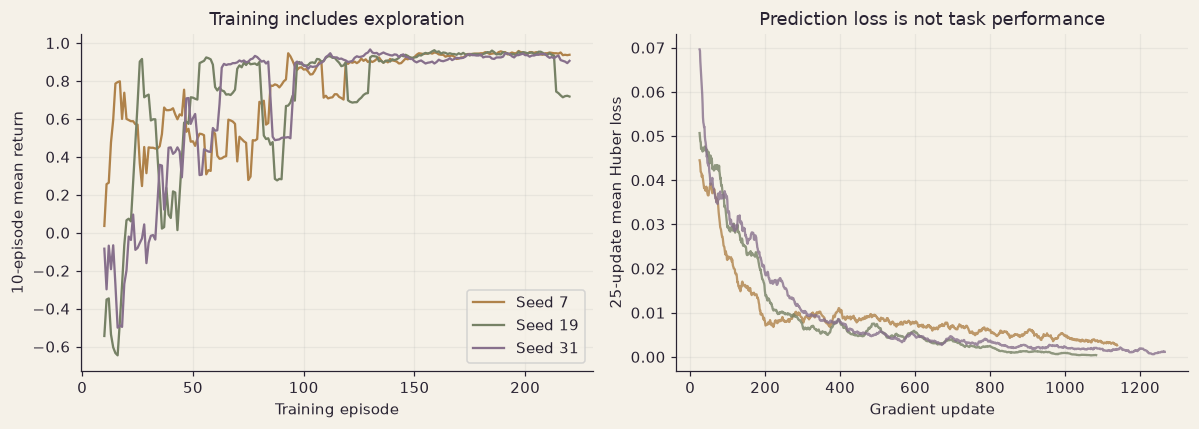

In [6]:
def evaluate(network=None, episodes=200, seed=2026):
    env, rng = LineWorld(seed), np.random.default_rng(seed + 1)
    totals, successes = [], []
    with torch.no_grad():
        for _ in range(episodes):
            obs, total = env.reset(), 0.0
            while True:
                action = int(rng.integers(2)) if network is None else int(network(torch.from_numpy(obs)).argmax())
                obs, reward, done, info = env.step(action)
                total += reward
                if done:
                    totals.append(total); successes.append(info['success']); break
    return float(np.mean(totals)), float(np.mean(successes))

baseline = evaluate()
scores = np.array([evaluate(network) for network, _, _ in runs])
print(f'Random policy: return {baseline[0]:.3f}, success {baseline[1]:.1%}')
for seed, (total, success) in zip(SEEDS, scores):
    print(f'DQN seed {seed}: return {total:.3f}, success {success:.1%}')
assert scores[:, 1].mean() > baseline[1], 'Investigate learning before interpreting plots'
assert all(np.isfinite(losses).all() for _, _, losses in runs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for seed, (_, returns, losses) in zip(SEEDS, runs):
    axes[0].plot(np.arange(10, len(returns)+1), np.convolve(returns, np.ones(10)/10, 'valid'), label=f'Seed {seed}')
    axes[1].plot(np.arange(25, len(losses)+1), np.convolve(losses, np.ones(25)/25, 'valid'), alpha=0.8)
axes[0].set(xlabel='Training episode', ylabel='10-episode mean return', title='Training includes exploration')
axes[1].set(xlabel='Gradient update', ylabel='25-update mean Huber loss', title='Prediction loss is not task performance')
axes[0].legend(); plt.tight_layout(); plt.show()

A good policy consistently moves toward delivery. A small TD loss alone does not prove that:
the network might predict a poor policy's outcomes accurately or fit a narrow replay dataset.
The separate success metric is therefore essential. With finite data and nonlinear networks,
target networks and replay improve practicality but do not supply the tabular convergence guarantee.

## Exercises

1. Set `target_every=1` and compare stability across the same seeds.
2. Try a much smaller replay buffer, keeping capacity at least the warmup.
3. Remove remaining time from the observation. Why is the task then partly observed?
4. Implement Double DQN: select the next action with the online network and evaluate it with the target network.

<details>
<summary>Hints and expected reasoning — open after trying the exercises</summary>

1. A target copied every step moves almost as fast as the predictor.
2. Less diversity and more correlated experience can matter. This toy task may remain easy.
3. The same position can have different prospects with 1 or 20 moves remaining.
4. Use argmax on online next-Q and gather from target next-Q, all without gradient tracking.

</details>

## What to remember

DQN learns action values from replayed transitions. Explicit terminal masks, fixed targets, shape checks, and separate evaluation are the core implementation habits.

## Further reading

- Mnih et al., [Human-level control through deep reinforcement learning](https://doi.org/10.1038/nature14236).
- Sutton and Barto, [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html). Chapter 11 on off-policy approximation.

## Experiment summary

These values are computed from this run. Compare the evaluation setting and seeds before interpreting a difference; training reward, success, and estimation error answer different questions.

In [7]:
from IPython.display import Markdown, display
def result_table(headers, rows):
    clean = lambda value: str(value).replace('|', '&#124;').replace('\n', '<br>')
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
                     '\n'.join('| ' + ' | '.join(map(clean, row)) + ' |' for row in rows)))
result_table(['Policy', 'Mean evaluation return', 'Success rate'],
    [['Random', f'{baseline[0]:.3f}', f'{baseline[1]:.1%}']] +
    [[f'DQN seed {seed}', f'{score[0]:.3f}', f'{score[1]:.1%}'] for seed, score in zip(SEEDS, scores)])

| Policy | Mean evaluation return | Success rate |
|---|---|---|
| Random | -0.131 | 42.5% |
| DQN seed 7 | 0.941 | 100.0% |
| DQN seed 19 | 0.941 | 100.0% |
| DQN seed 31 | 0.941 | 100.0% |

[← Previous notebook](03_q_learning.ipynb) · [Next notebook →](05_policy_gradient.ipynb)